In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# Árboles de decisión

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_graphviz
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error

In [5]:
# Cargamos el dataset
X_train = pd.read_csv("../datasets/X_train.csv")
X_test = pd.read_csv("../datasets/X_test.csv")
y_train = pd.read_csv("../datasets/y_train.csv")
y_test = pd.read_csv("../datasets/y_test.csv")


In [6]:
X_train.dropna(subset=['gender'], inplace=True)
y_train = y_train.loc[X_train.index]

In [7]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3576, 15), (1533, 15), (3576, 1), (1533, 1))

In [8]:
X_train.isnull().sum()

age                               0
avg_glucose_level                 0
bmi                               0
hypertension                      0
heart_disease                     0
gender                            0
ever_married                      0
Residence_type                    0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64

In [9]:
y_train.value_counts()

stroke
0         3402
1          174
Name: count, dtype: int64

Las clases están muy desbalanceadas, entonces vamos a usar DecisionTreeClassifier con class_weight = 'balanced', de este modo utiliza los valores de y para ajustar automáticamente los pesos inversamente proporcionales a las frecuencias de clase en los datos de entrada como n_samples / (n_classes * np.bincount(y))

Ahora vamos a aplicar el modelo, primero llamamos al modelo de [árbol de clasificación](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

In [10]:
from sklearn.tree import DecisionTreeClassifier

# Creamos el arbol
classification = DecisionTreeClassifier(criterion='entropy', splitter='best', class_weight='balanced',
                                        max_depth=None, min_samples_split=2, min_samples_leaf=1, 
                                        random_state=42)
# Y entrenamos
classification.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       random_state=42)

In [11]:
classification.get_params()

{'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Podemos ver a nuestro arbol para entender que hizo usando export_graphviz

In [12]:
export_graphviz(classification, out_file = "arbol_clasificacion.dot",
                feature_names=X_train.columns,
                class_names=["No tiene enfermedad cardiaca", "Tiene enfermedad cardiaca"],
                rounded=True,
                filled=True)

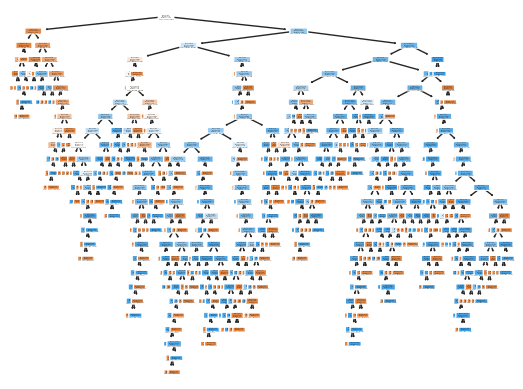

In [13]:
from sklearn.tree import plot_tree
plot_tree(classification, filled=True, rounded=True);

Midamos como este modelo performa usando el F1-score:

In [ ]:
y_pred_train = classification.predict(X_train)
y_pred = classification.predict(X_test)

f1_train = f1_score(y_train, y_pred_train)
f1 = f1_score(y_test, y_pred)

print(f"F1-score de entreamiento fue: {f1_train}")
print(f"F1-score de testeo fue: {f1}")

F1-score de entreamiento fue: 1.0
F1-score de testeo fue: 0.5431401943430987


F1-score fue muy bajo para el testeo, lo cual muestra que el modelo no es muy robusto

In [26]:
classification.get_params()

{'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Podemos hacer una búsqueda de hiper-parámetros pero buscando con otros parámetros del modelo, usando optuna:

In [27]:
import optuna 

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 1, 30)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])
    class_weight = trial.suggest_categorical("class_weight", ["balanced", None])
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)

    classifier = DecisionTreeClassifier(criterion=criterion, splitter='best', class_weight=class_weight,
                                        max_depth=max_depth, min_samples_split=min_samples_split, 
                                        min_samples_leaf=min_samples_leaf, random_state=42)
    
    # Realizamos la validación cruzada
    score = cross_val_score(classifier, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
    
    return score.mean()

In [28]:
def champion_callback(study, frozen_trial):
    """
    Mostramos menos información, sino es demasiado verboso
    """
    winner = study.user_attrs.get("winner", None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value) * 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} with "
                f"{improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: {frozen_trial.value}")

In [29]:
# Creamos un estudio de Optuna
# Optuna es un poco verboso, dejamos que solo nos muestre logs de errores
optuna.logging.set_verbosity(optuna.logging.ERROR)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=1000, callbacks=[champion_callback])

Initial trial 0 achieved value: 0.15285291077252022
Trial 1 achieved value: 0.19693454389328968 with  22.3839% improvement
Trial 5 achieved value: 0.20136057069035207 with  2.1981% improvement
Trial 11 achieved value: 0.20163009862433565 with  0.1337% improvement
Trial 42 achieved value: 0.20187991032032845 with  0.1237% improvement
Trial 46 achieved value: 0.20494275538154194 with  1.4945% improvement
Trial 48 achieved value: 0.20597145775281459 with  0.4994% improvement
Trial 49 achieved value: 0.20976177996516357 with  1.8070% improvement
Trial 58 achieved value: 0.21032245418748485 with  0.2666% improvement
Trial 62 achieved value: 0.21043192465677968 with  0.0520% improvement
Trial 68 achieved value: 0.21044916584735346 with  0.0082% improvement
Trial 185 achieved value: 0.21290187063657245 with  1.1520% improvement
Trial 217 achieved value: 0.21525018063597195 with  1.0910% improvement
Trial 308 achieved value: 0.21526108812039957 with  0.0051% improvement
Trial 309 achieved valu

In [30]:
# Obtenemos los mejores hiperparámetros encontrados
best_params = study.best_params
best_params

{'max_depth': 9,
 'criterion': 'entropy',
 'class_weight': 'balanced',
 'min_samples_split': 3,
 'min_samples_leaf': 1}

In [54]:
# Creamos el arbol
classification = DecisionTreeClassifier(**best_params, random_state=42)
# Y entrenamos
classification.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=9, min_samples_split=3, random_state=42)

In [56]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

y_pred = classification.predict(X_test)

metrics_tree = {
    "name": "Arbol de Clasificacion",
    "Recall": recall_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Accuracy": accuracy_score(y_test, y_pred),    
    "F1": f1_score(y_test, y_pred)
}

metrics_tree

{'name': 'Arbol de Clasificacion',
 'Recall': 0.6666666666666666,
 'Precision': 0.1347708894878706,
 'Accuracy': 0.7742987606001305,
 'F1': 0.2242152466367713}

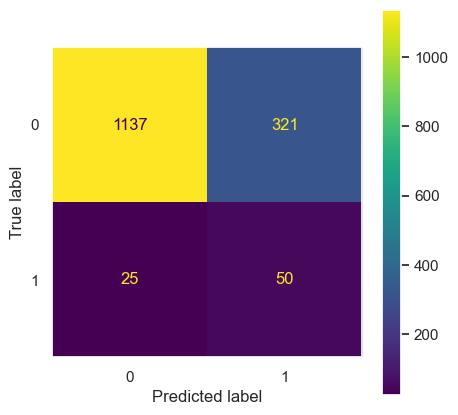

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=classification.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classification.classes_)

fig, ax = plt.subplots(figsize=(5,5))
ax.grid(False)
disp.plot(ax=ax);

Veamos la curva ROC:

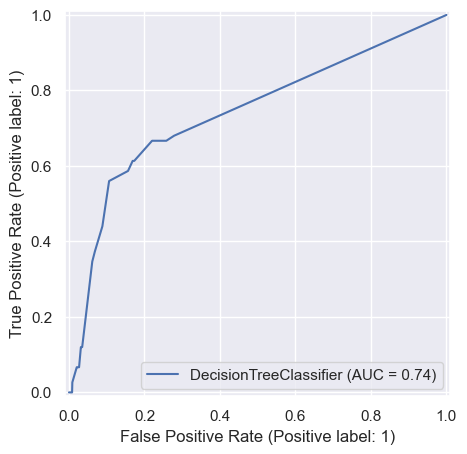

In [35]:
from sklearn.metrics import RocCurveDisplay
    
fig, ax = plt.subplots(figsize=(5,5))
svc_disp = RocCurveDisplay.from_estimator(classification, X_test, y_test, ax=ax)

plt.show();

In [36]:
X = X_train.loc[:, ['smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes', 'heart_disease', 'age']].values
y = y_train.values

# Creamos el arbol
classification = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Y entrenamos
classification.fit(X, y)

DecisionTreeClassifier(criterion='entropy', random_state=42)

### Bagging

In [37]:
from sklearn.ensemble import BaggingClassifier

# Creamos un Bagging con 20 estimadores (20 árboles)
bagging_classifier = BaggingClassifier(estimator=classification, n_estimators=20, random_state=42, n_jobs=-1)
bagging_classifier.fit(X_train, y_train)

# Calculamos las métricas
y_pred_bag = bagging_classifier.predict(X_test)

metrics_bag = {
    "name": "Bagging",
    "Recall": recall_score(y_test, y_pred_bag),
    "Precision": precision_score(y_test, y_pred_bag),
    "Accuracy": accuracy_score(y_test, y_pred_bag),    
    "F1": f1_score(y_test, y_pred_bag, average='macro')
}

metrics_bag

c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


{'name': 'Bagging',
 'Recall': 0.02666666666666667,
 'Precision': 0.3333333333333333,
 'Accuracy': 0.9497716894977168,
 'F1': 0.5117935355791302}

### Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier

# Creamos un bosque aleatorio por defecto (100 árboles)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Calculamos las métricas
y_pred_rf = rf_classifier.predict(X_test)

metrics_rf = {
    "name": "Random Forest",
    "Recall": recall_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Accuracy": accuracy_score(y_test, y_pred_rf),    
    "F1": f1_score(y_test, y_pred_rf, average='macro')
}

metrics_rf

c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


{'name': 'Random Forest',
 'Recall': 0.0,
 'Precision': 0.0,
 'Accuracy': 0.9497716894977168,
 'F1': 0.48711943793911006}

### Boosting

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Inicializamos el árbol (weak learner)
base_estimator = DecisionTreeClassifier(max_depth=6)

# Configuramos también la cantidad y la constante de aprendizaje
adaboost_classifier = AdaBoostClassifier(estimator=base_estimator, n_estimators=500, random_state=42, learning_rate=0.01)
adaboost_classifier.fit(X_train, y_train)

# Calculamos las métricas
y_pred_ada = adaboost_classifier.predict(X_test)

metrics_ada = {
    "name": "AdaBoost",
    "Recall": recall_score(y_test, y_pred_ada),
    "Precision": precision_score(y_test, y_pred_ada),
    "Accuracy": accuracy_score(y_test, y_pred_ada),    
    "F1": f1_score(y_test, y_pred_ada)
}

metrics_ada

c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


{'name': 'AdaBoost',
 'Recall': 0.0,
 'Precision': 0.0,
 'Accuracy': 0.9504240052185258,
 'F1': 0.4872909698996655}

### XGBoost

In [41]:
import xgboost as xgb

# Inicializamos XGBoost con sus hiperparámetros por defecto
xgb_classifier = xgb.XGBClassifier(random_state=42, n_jobs=-1, max_depth=100)
xgb_classifier.fit(X_train, y_train)

# Calculamos las métricas
y_pred_xgb = xgb_classifier.predict(X_test)

metrics_xgb = {
    "name": "XGBoost",
    "Recall": recall_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Accuracy": accuracy_score(y_test, y_pred_xgb),    
    "F1": f1_score(y_test, y_pred_xgb)
}
metrics_xgb

{'name': 'XGBoost',
 'Recall': 0.05333333333333334,
 'Precision': 0.16666666666666666,
 'Accuracy': 0.9406392694063926,
 'F1': 0.08080808080808081}

In [57]:
models_metrics = [metrics_ada, metrics_rf, metrics_bag, metrics_xgb, metrics_tree] 

# Crear el DataFrame
df_results = pd.DataFrame(models_metrics)

# (Opcional) Poner el nombre como índice para que sea la primera columna
df_results.set_index('name', inplace=True)

print(df_results)

                          Recall  Precision  Accuracy        F1
name                                                           
AdaBoost                0.000000   0.000000  0.950424  0.487291
Random Forest           0.000000   0.000000  0.949772  0.487119
Bagging                 0.026667   0.333333  0.949772  0.511794
XGBoost                 0.053333   0.166667  0.940639  0.080808
Arbol de Clasificacion  0.666667   0.134771  0.774299  0.224215


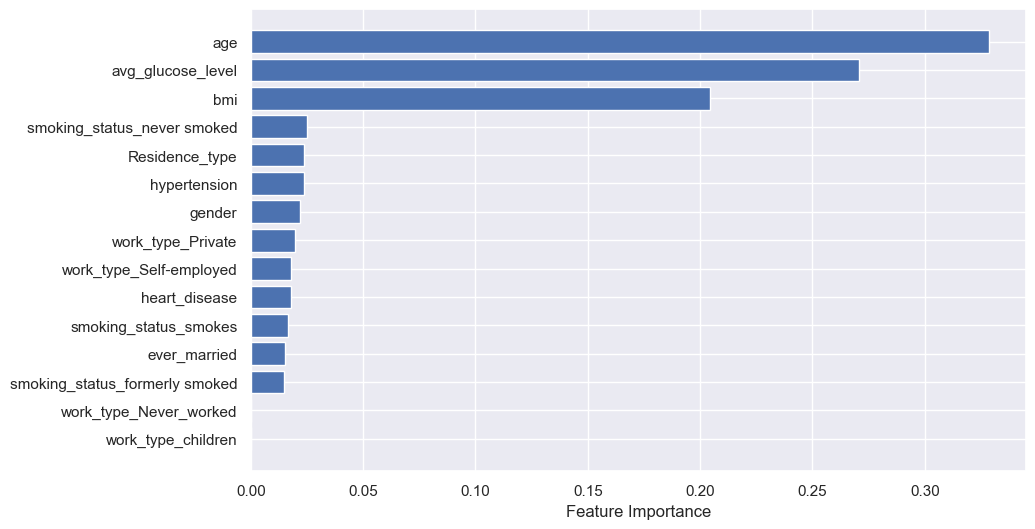

In [47]:
# Obtenemos la importancia de características
feature_importances = np.mean([tree.feature_importances_ for tree in bagging_classifier.estimators_], axis=0)
feature_names = X_test.columns

# Ordenamos los índices
sorted_idx = feature_importances.argsort()

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.show()

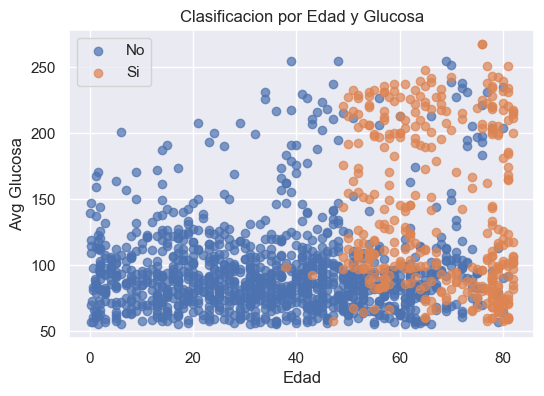

In [70]:
plt.figure(figsize=(6, 4))
for i, target_name in enumerate(["No", "Si"]):
    plt.scatter(X_test[y_pred == i]['age'], X_test[y_pred == i]['avg_glucose_level'], label=target_name, alpha=0.7)
plt.xlabel("Edad")
plt.ylabel("Avg Glucosa")
plt.legend()
plt.title("Clasificacion por Edad y Glucosa")
plt.show()